# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
from dns.e164 import query
from numpy.ma.core import mean
from skimage.data import rocket

from day_072.project.data_exploration_major_salaries import clean_df
%pip install iso3166


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 5.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: plotly
    Found existing installation: plotly 6.7.0
    Uninstalling plotly-6.7.0:
      Successfully uninstalled plotly-6.7.0

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import Statements

In [57]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
df_data.shape

(4324, 9)

In [10]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [7]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='str')

In [13]:
df_data.isna().values.any()


np.True_

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [25]:
clean_df = df_data.loc[:, ~df_data.columns.str.contains("^Unnamed")]

In [26]:
clean_df.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status'],
      dtype='str')

## Descriptive Statistics

In [28]:
clean_df.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [29]:
launches_per_company = clean_df["Organisation"].value_counts()

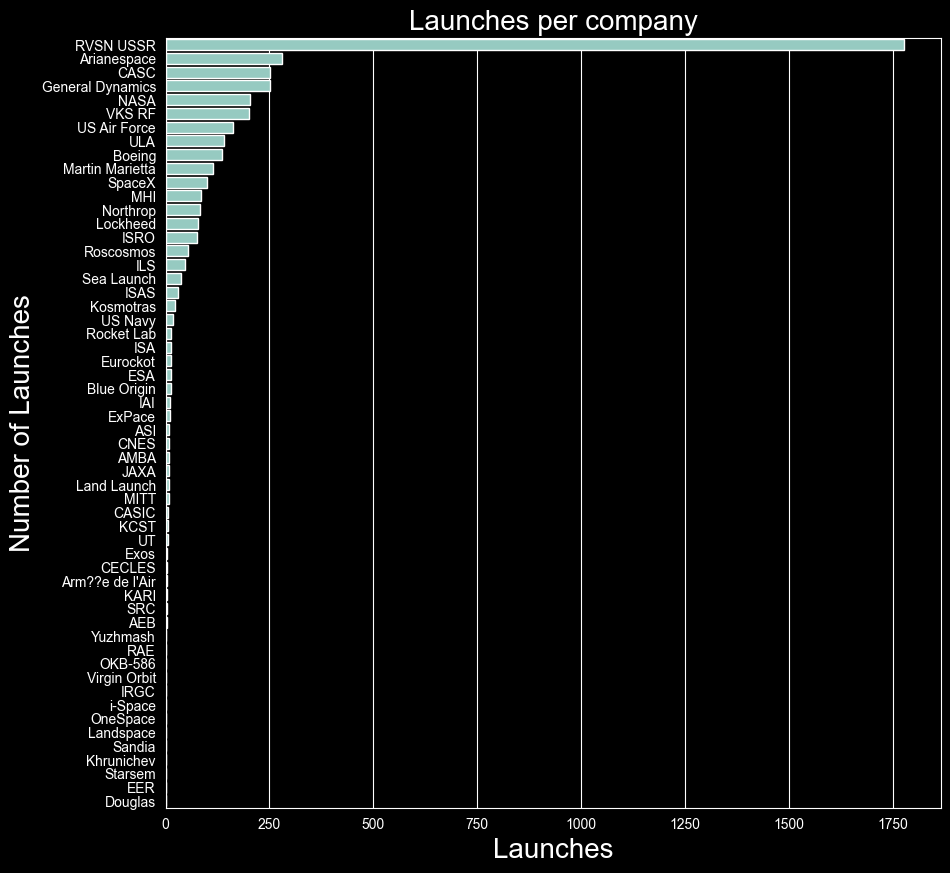

In [33]:
plt.figure(figsize=(10,10))
plt.title("Launches per company", fontsize=20)
plt.xlabel("Launches", fontsize=20)
plt.ylabel("Number of Launches", fontsize=20)

sns.barplot(
    x=launches_per_company.values,
    y=launches_per_company.index,
)

plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [34]:
clean_df["Rocket_Status"].value_counts()

Rocket_Status
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

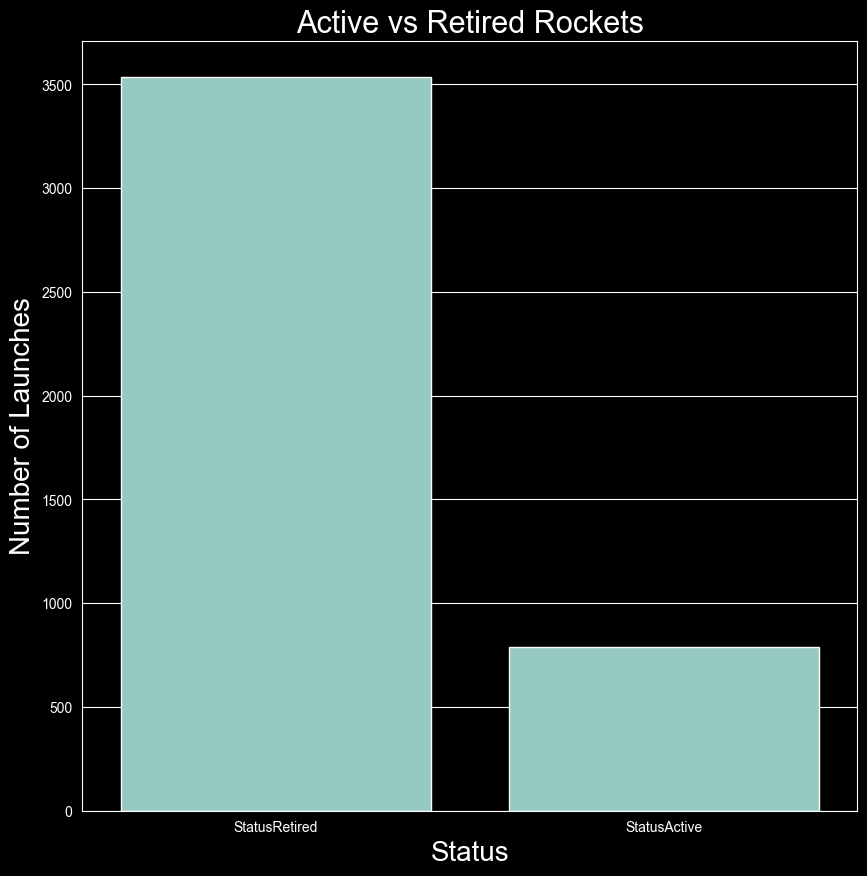

In [39]:
rocket_status = ( clean_df["Rocket_Status"].value_counts().reset_index())

rocket_status.columns = ["Status", "Count"]

plt.figure(figsize=(10,10))
plt.title("Active vs Retired Rockets", fontsize=22)

sns.barplot(
    data=rocket_status,
    x="Status",
    y="Count",
)

plt.xlabel("Status", fontsize=20)
plt.ylabel("Number of Launches", fontsize=20)


plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [40]:
clean_df["Mission_Status"].value_counts()

Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

In [43]:
status_of_success = (clean_df["Mission_Status"].value_counts().reset_index())
status_of_success.columns = ["Status", "Count"]

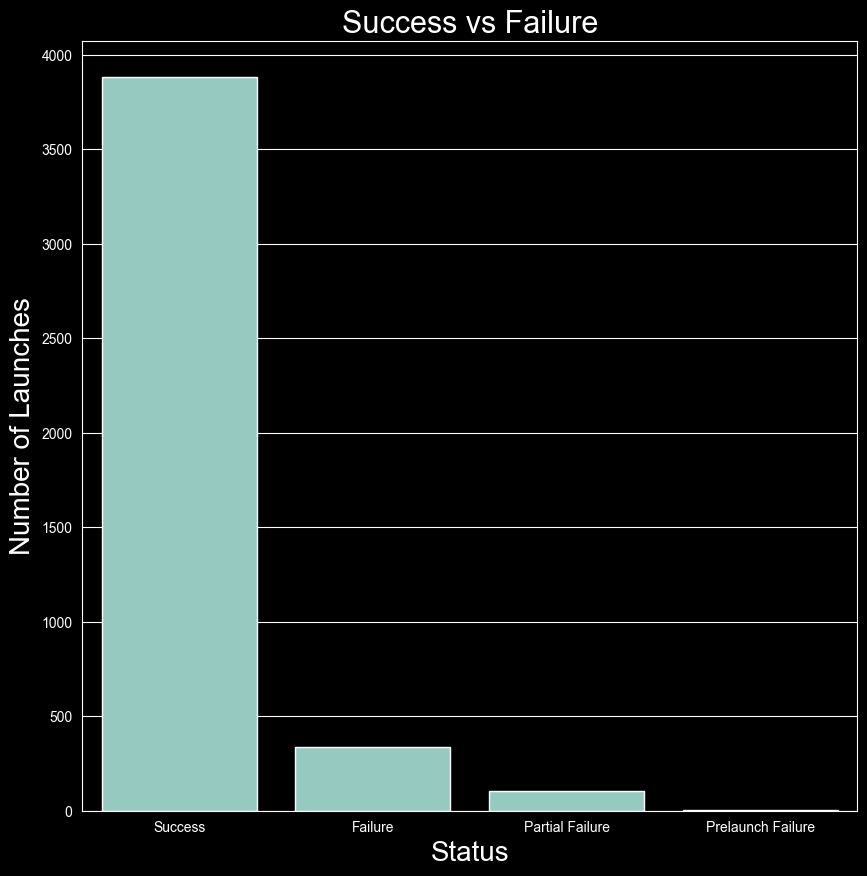

In [44]:
plt.figure(figsize=(10,10))
plt.title("Success vs Failure", fontsize=22)

sns.barplot(
    data=status_of_success,
    x="Status",
    y="Count",
)

plt.xlabel("Status", fontsize=20)
plt.ylabel("Number of Launches", fontsize=20)


plt.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [45]:
clean_df["Price"]

0        50.0
1       29.75
2         NaN
3        65.0
4       145.0
        ...  
4319      NaN
4320      NaN
4321      NaN
4322      NaN
4323      NaN
Name: Price, Length: 4324, dtype: str

In [48]:
price_df = clean_df.dropna(subset=["Price"])
price_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


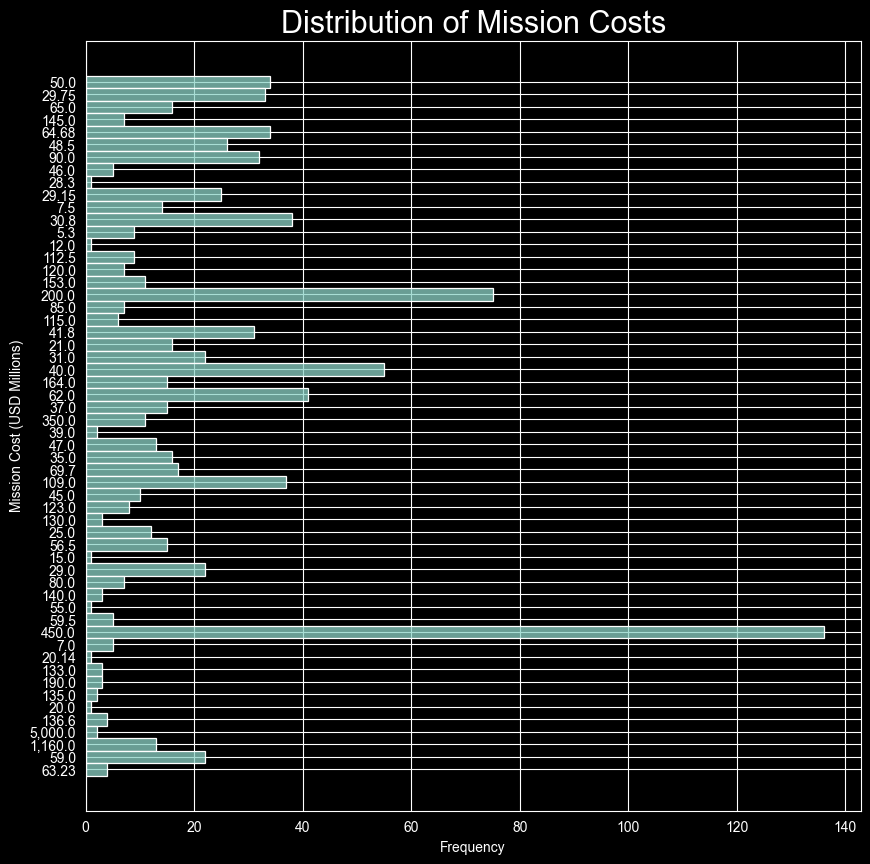

In [55]:
plt.figure(figsize=(10,10))
plt.title("Distribution of Mission Costs", fontsize=22)

sns.histplot(
    data=price_df,
    y="Price",
    bins=10,
)

plt.xlabel("Frequency")
plt.ylabel("Mission Cost (USD Millions)")

plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [58]:
clean_df["Country"] = clean_df["Location"].str.split(",").str[-1].str.strip()

In [60]:
country_replacements = {
    "Russia": "Russian Federation",
    "New Mexico": "USA",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "USA",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "USA",
}

clean_df["Country"] = clean_df["Country"].replace(country_replacements)

In [61]:
def get_alpha3(country_name):
    try:
        return countries.get(country_name).alpha3
    except:
        return None


clean_df["Alpha3"] = clean_df["Country"].apply(get_alpha3)

In [62]:
clean_df[clean_df["Alpha3"].isna()]["Country"].unique()

array(['Iran', 'North Korea', 'Pacific Ocean', 'South Korea'],
      dtype=object)

In [63]:
launches_by_country = (
    clean_df.groupby(["Country", "Alpha3"])
    .size()
    .reset_index(name="Launches")
)

launches_by_country.head()

,Country,Alpha3,Launches
0,Australia,AUS,6
1,Brazil,BRA,3
2,China,CHN,269
3,France,FRA,303
4,India,IND,76


# Use a Choropleth Map to Show the Number of Failures by Country


In [64]:
fig = px.choropleth(
    launches_by_country,
    locations="Alpha3",
    color="Launches",
    hover_name="Country",
    color_continuous_scale="matter",
    title="Number of Space Mission Launches by Country"
)

fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [65]:
fig = px.sunburst(
    clean_df,
    path=["Country", "Organisation", "Mission_Status"],
    title="Space Missions by Country, Organisation, and Mission Status"
)

fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [152]:
price_df["Price"] = pd.to_numeric(price_df["Price"],errors="coerce")

In [67]:
spending = (
    price_df.groupby("Organisation")["Price"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

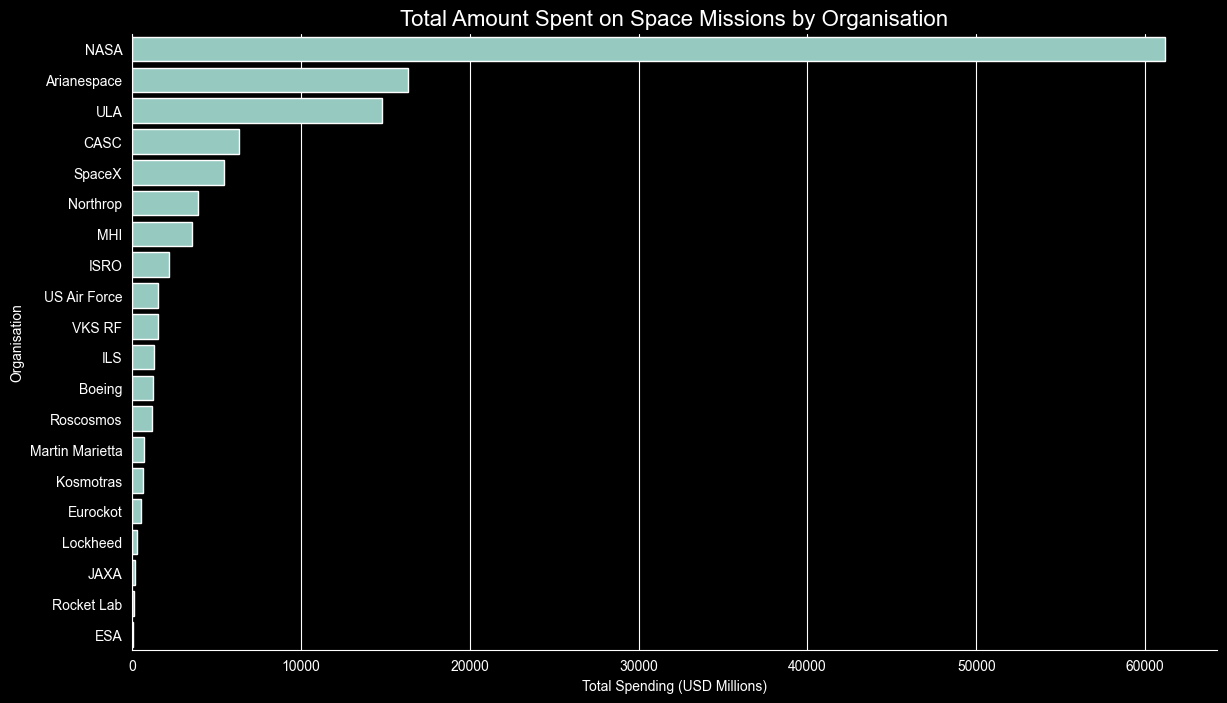

In [68]:
spending_df = spending.reset_index()

spending_df.columns = [
    "Organisation",
    "Total_Spending"
]

plt.figure(figsize=(14, 8))

sns.barplot(
    data=spending_df,
    x="Total_Spending",
    y="Organisation"
)

plt.title(
    "Total Amount Spent on Space Missions by Organisation",
    fontsize=16
)

plt.xlabel("Total Spending (USD Millions)")
plt.ylabel("Organisation")

sns.despine()

plt.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [69]:
cost_per_launch = (
    price_df
    .groupby("Organisation")
    .agg({
        "Price": ["sum", "count"]
    })
)

cost_per_launch.columns = [
    "Total_Spent",
    "Launches"
]

cost_per_launch.head()

,Total_Spent,Launches
Organisation,,
Arianespace,"16,345.00",96
Boeing,"1,241.00",7
CASC,"6,340.26",158
EER,20.00,1
ESA,37.00,1


In [77]:
avg_cost = (
    price_df
    .groupby("Organisation")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Cost of Space Missions by Organisation Per Launch")
print(avg_cost)
avg_cost.head()

Average Cost of Space Missions by Organisation Per Launch
Organisation
NASA              450.00
Boeing            177.29
Arianespace       170.26
ULA               151.00
ILS               101.54
MHI                95.47
Martin Marietta    80.16
US Air Force       59.65
JAXA               56.00
SpaceX             54.99
Roscosmos          51.63
Northrop           47.35
VKS RF             46.94
Eurockot           41.80
CASC               40.13
ESA                37.00
Lockheed           35.00
ISRO               32.49
Kosmotras          29.00
ExPace             28.30
EER                20.00
Sandia             15.00
Virgin Orbit       12.00
Rocket Lab          7.50
RVSN USSR            NaN
Name: Price, dtype: float64


Organisation
NASA          450.00
Boeing        177.29
Arianespace   170.26
ULA           151.00
ILS           101.54
Name: Price, dtype: float64

# Chart the Number of Launches per Year

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [81]:
clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce"
)

In [89]:
clean_df = clean_df[clean_df["Date"].notna()]

In [98]:
clean_df["Month"] = clean_df["Date"].dt.month

In [99]:
month_counts = (
    clean_df["Month"]
    .value_counts()
    .sort_index()
)

month_counts

Month
1     265
2     323
3     349
4     366
5     320
6     386
7     347
8     358
9     354
10    375
11    325
12    430
Name: count, dtype: int64

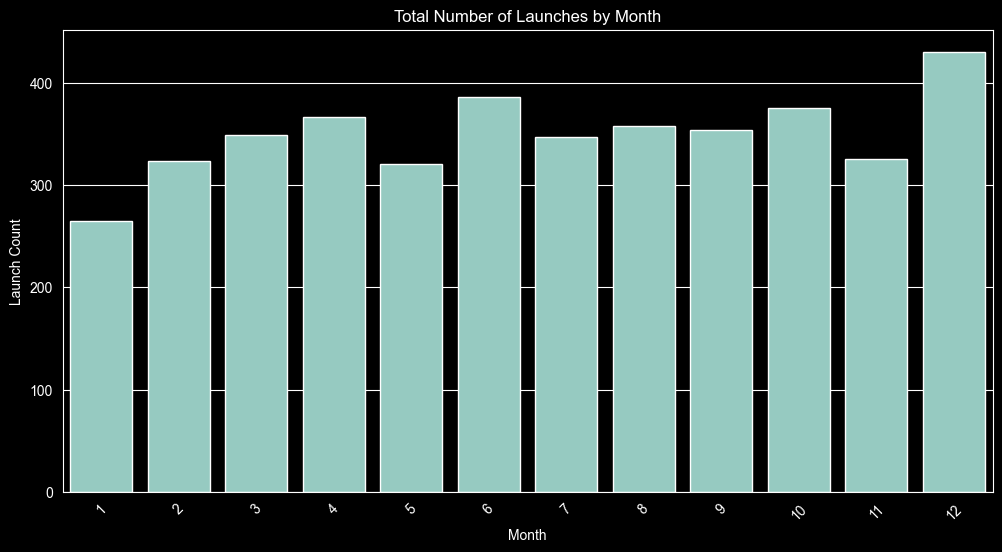

In [100]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=month_counts.index,
    y=month_counts.values
)

plt.title(
    "Total Number of Launches by Month"
)

plt.xlabel("Month")
plt.ylabel("Launch Count")

plt.xticks(rotation=45)

plt.show()

In [102]:
print(f"Highest number of launcehs was in month: {clean_df["Month"].max()}")

Highest number of launcehs was in month: 12


# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [103]:
print(f"Most popular month: {clean_df["Month"].max()}")

Most popular month: 12


In [104]:
print(f"Least popular month: {clean_df["Month"].min()}")


Least popular month: 1


# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time.

In [107]:
price_df["Date"] = pd.to_datetime(
    price_df["Date"],
    errors="coerce"
)

price_df = price_df.dropna(
    subset=["Date", "Price"]
)

In [108]:
avg_price_per_year = (
    price_df
    .groupby(price_df["Date"].dt.year)["Price"]
    .mean()
    .reset_index()
)

avg_price_per_year.columns = [
    "Year",
    "Average_Price"
]

avg_price_per_year.head()

,Year,Average_Price
0,1964,63.23
1,1965,63.23
2,1966,59.00
3,1967,59.00
4,1968,59.00


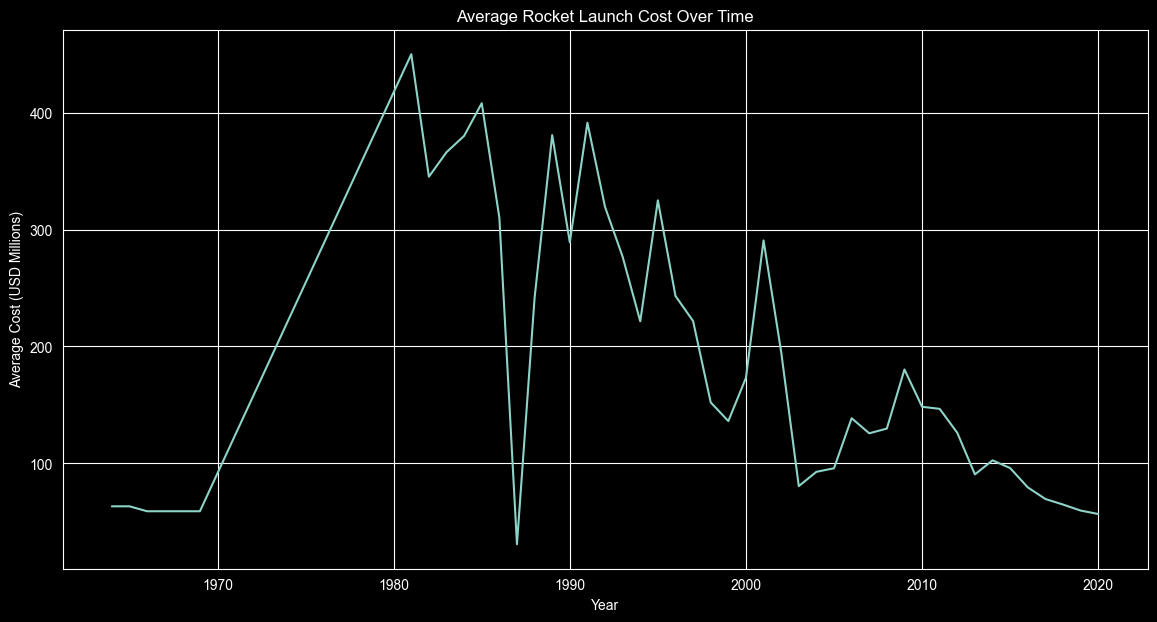

In [109]:

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=avg_price_per_year,
    x="Year",
    y="Average_Price"
)

plt.title(
    "Average Rocket Launch Cost Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average Cost (USD Millions)")

plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [111]:
clean_df["Year"] = clean_df["Date"].dt.year
clean_df["Year"]

0       2020
1       2020
2       2020
3       2020
4       2020
        ... 
4319    1958
4320    1958
4321    1957
4322    1957
4323    1957
Name: Year, Length: 4198, dtype: int32

In [112]:
top_orgs = (
    clean_df["Organisation"]
    .value_counts()
    .head(10)
    .index
)

In [115]:
top_df = clean_df[
    clean_df["Organisation"].isin(top_orgs)
]

In [116]:
launches_by_year = (
    top_df
    .groupby(
        ["Year", "Organisation"]
    )
    .size()
    .reset_index(
        name="Launches"
    )
)

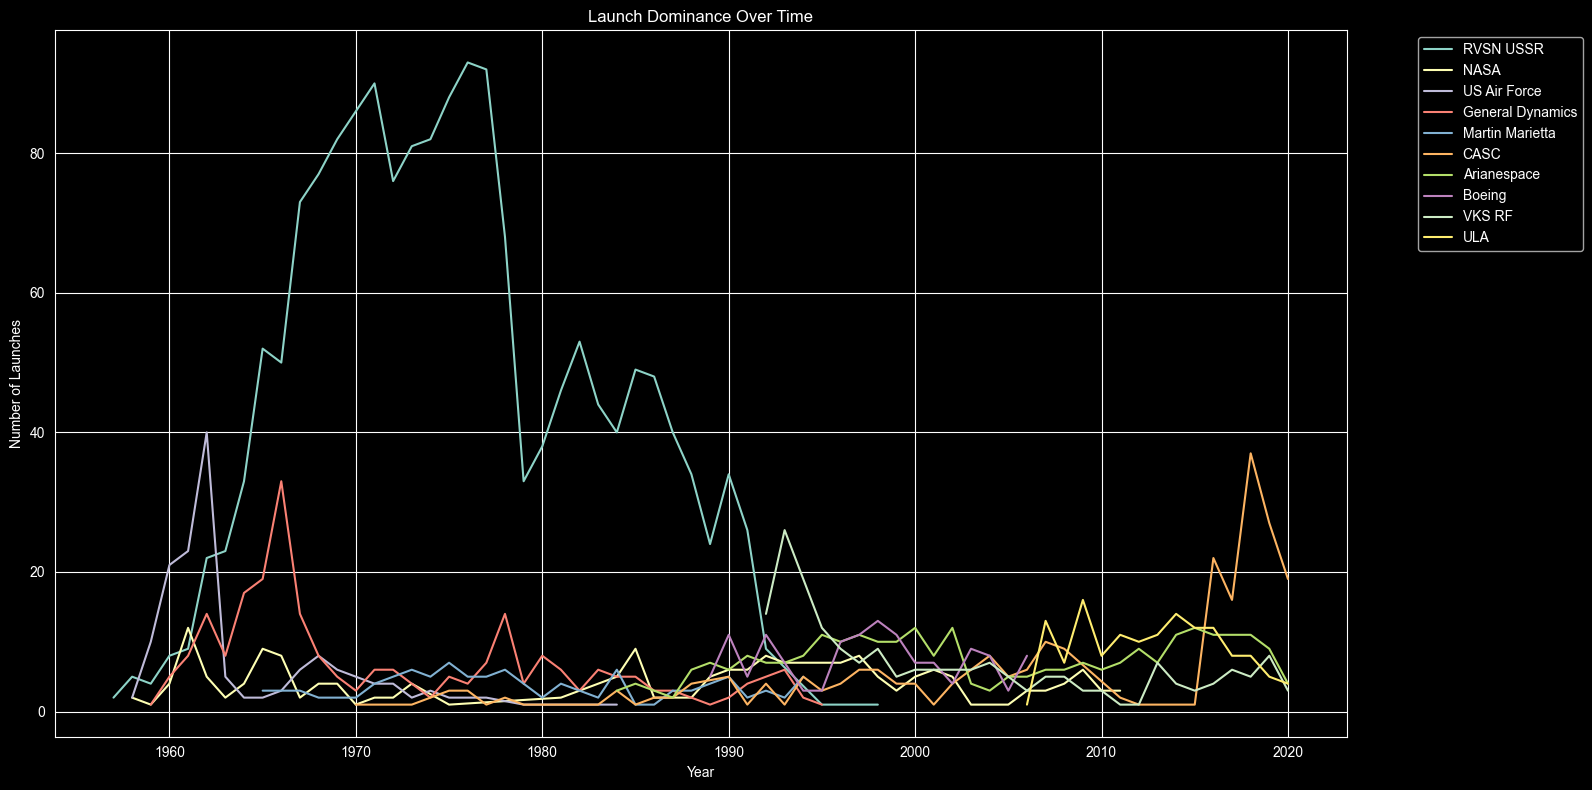

In [119]:
plt.figure(figsize=(16,8))

sns.lineplot(
    data=launches_by_year,
    x="Year",
    y="Launches",
    hue="Organisation"
)

plt.title(
    "Launch Dominance Over Time"
)

plt.xlabel("Year")
plt.ylabel("Number of Launches")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [120]:
cold_war_df = clean_df[
    (clean_df["Date"].dt.year >= 1957)
    &
    (clean_df["Date"].dt.year <= 1991)
]

In [122]:
usa_vs_ussr = clean_df[
    clean_df["Organisation"].isin(
        [
            "NASA",
            "RVSN USSR"
        ]
    )
]

In [123]:
race = (
    usa_vs_ussr
    .groupby(
        [
            usa_vs_ussr["Date"].dt.year,
            "Organisation"
        ]
    )
    .size()
    .reset_index(
        name="Launches"
    )
)

race.columns = [
    "Year",
    "Organisation",
    "Launches"
]

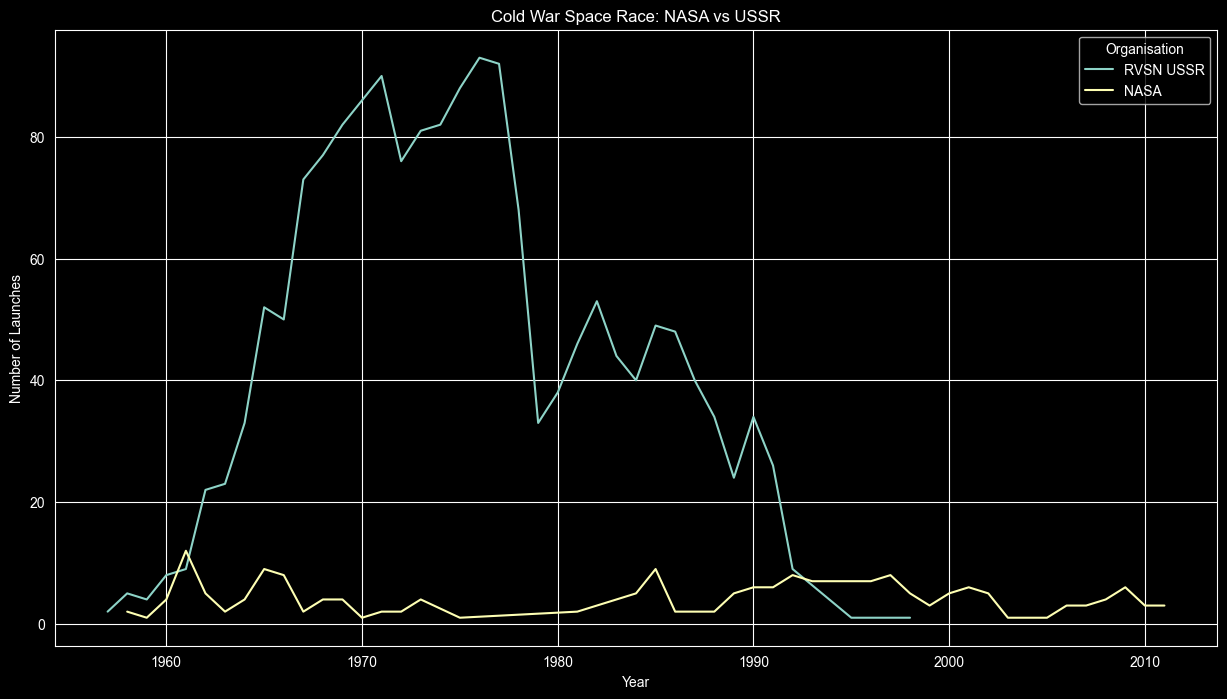

In [124]:
plt.figure(figsize=(15,8))

sns.lineplot(
    data=race,
    x="Year",
    y="Launches",
    hue="Organisation"
)

plt.title(
    "Cold War Space Race: NASA vs USSR"
)

plt.ylabel(
    "Number of Launches"
)

plt.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [125]:
cold_war_df["Superpower"] = cold_war_df["Country"].replace({
    "USA": "USA",
    "Russian Federation": "RVSN USSR",
})

In [131]:
cold_war_df["Superpower"].head()

1717        China
1719    RVSN USSR
1720       France
1721          USA
1722          USA
Name: Superpower, dtype: object

In [132]:
superpower_df = cold_war_df[
    cold_war_df["Superpower"].isin(
        ["USA", "RVSN USSR"]
    )
]

In [133]:
launch_counts = (
    superpower_df["Superpower"]
    .value_counts()
    .reset_index()
)

launch_counts.columns = [
    "Superpower",
    "Launches"
]

launch_counts

,Superpower,Launches
0,RVSN USSR,1146
1,USA,644


## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [134]:
launches_per_year = (
    superpower_df
    .groupby(
        [
            superpower_df["Date"].dt.year,
            "Superpower"
        ]
    )
    .size()
    .reset_index(name="Launches")
)

launches_per_year.columns = [
    "Year",
    "Superpower",
    "Launches"
]

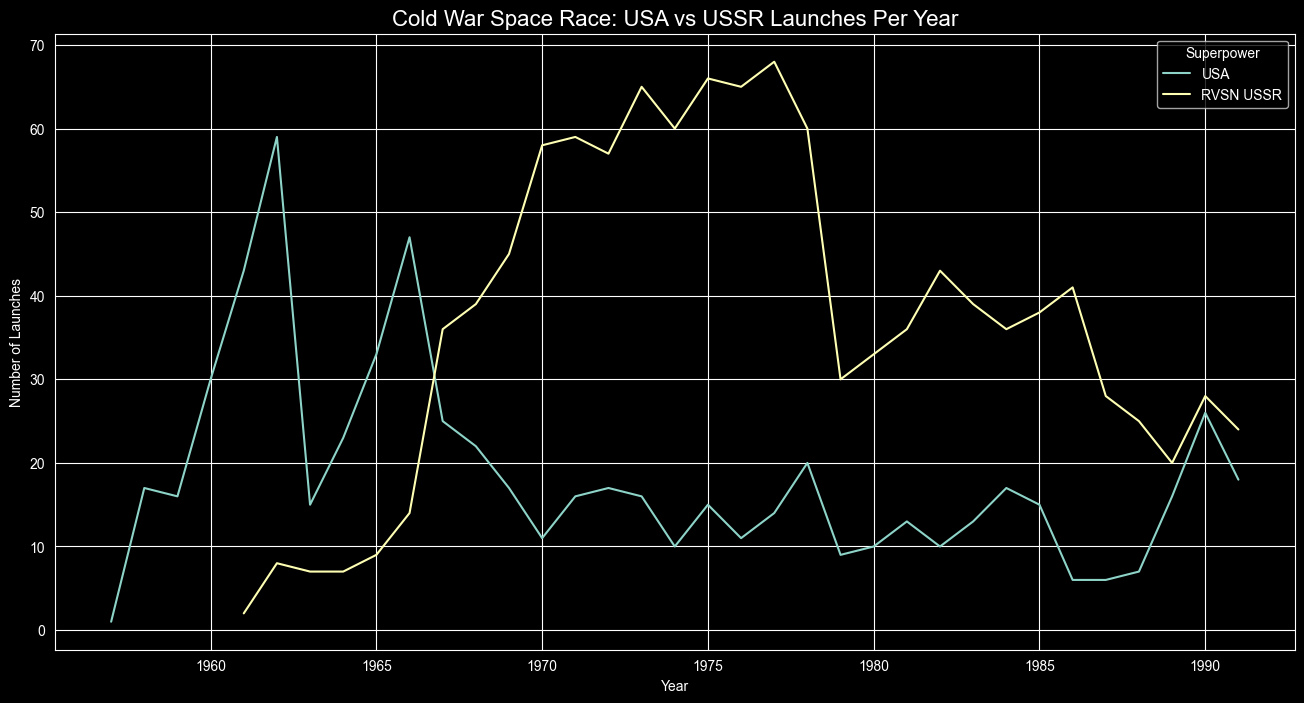

In [135]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=launches_per_year,
    x="Year",
    y="Launches",
    hue="Superpower"
)

plt.title(
    "Cold War Space Race: USA vs USSR Launches Per Year",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Launches")

plt.show()

## Chart the Total Number of Mission Failures Year on Year.

In [136]:
failures = clean_df[clean_df["Mission_Status"] == "Failure"]

In [137]:
failures_per_year = (
    failures
    .groupby(failures["Date"].dt.year)
    .size()
    .reset_index(name="Failures")
)

failures_per_year.columns = [
    "Year",
    "Failures"
]

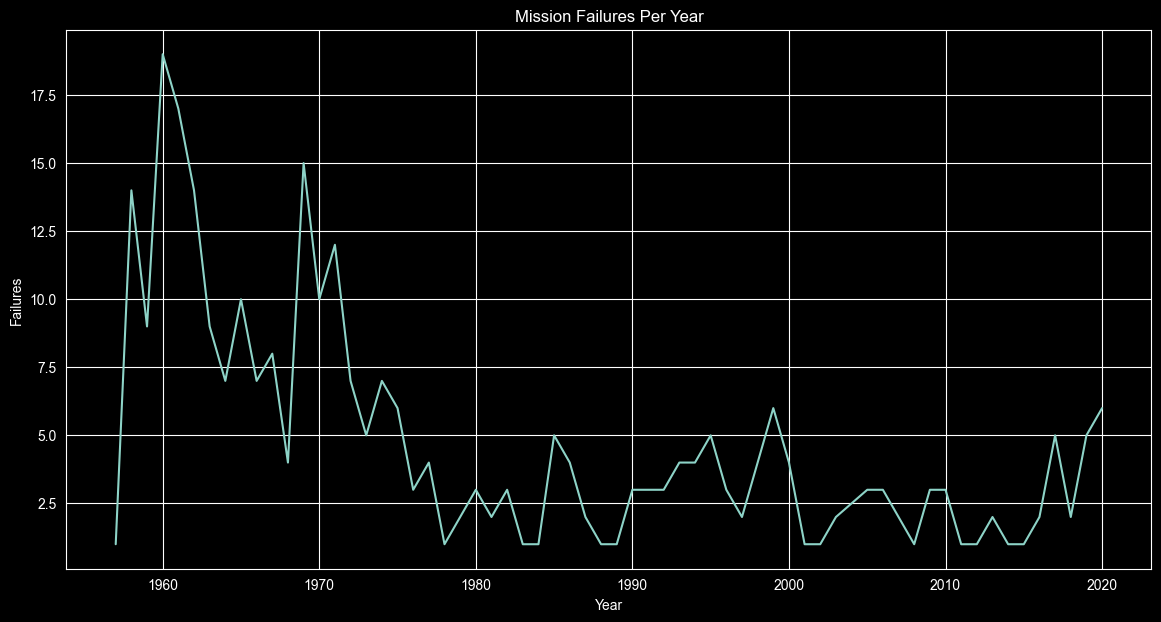

In [138]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=failures_per_year,
    x="Year",
    y="Failures"
)

plt.title("Mission Failures Per Year")
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [141]:
failures = (
    clean_df[clean_df["Mission_Status"] == "Failure"]
    .groupby(clean_df["Date"].dt.year)
    .size()
    .reset_index(name="Failures")
)

In [139]:
total_launches = (
    clean_df
    .groupby(clean_df["Date"].dt.year)
    .size()
    .reset_index(name="Total")
)

In [142]:
failure_rate = total_launches.merge(
    failures,
    on="Date",
    how="left"
)

failure_rate.fillna(0, inplace=True)

,Date,Total,Failures
0,1957,3,1.00
1,1958,22,14.00
2,1959,20,9.00
3,1960,38,19.00
4,1961,52,17.00
...,...,...,...
59,2016,88,2.00
60,2017,90,5.00
61,2018,117,2.00
62,2019,107,5.00


In [143]:
failure_rate["Failure_Rate"] = (
    failure_rate["Failures"]
    / failure_rate["Total"]
) * 100

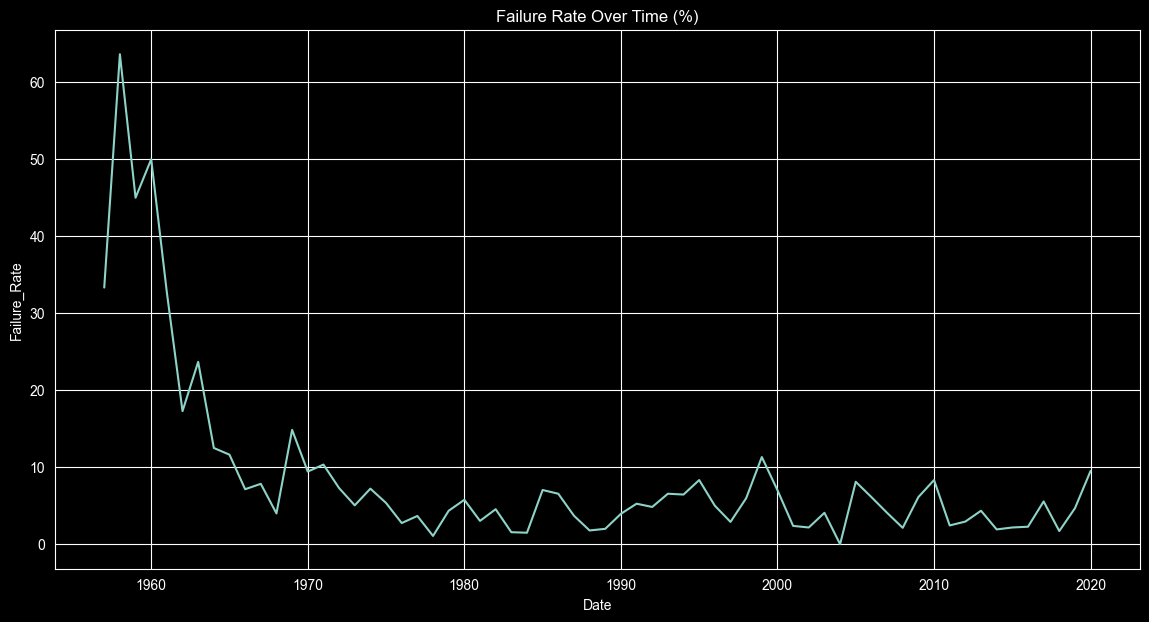

In [144]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=failure_rate,
    x="Date",
    y="Failure_Rate"
)

plt.title("Failure Rate Over Time (%)")

plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [145]:
country_launches = (
    clean_df
    .groupby(
        [
            clean_df["Date"].dt.year,
            "Country"
        ]
    )
    .size()
    .reset_index(name="Launches")
)

country_launches.columns = [
    "Year",
    "Country",
    "Launches"
]

In [146]:
country_leaders = (
    country_launches
    .sort_values(
        "Launches",
        ascending=False
    )
    .groupby("Year")
    .first()
    .reset_index()
)

country_leaders.head()

,Year,Country,Launches
0,1957,Kazakhstan,2
1,1958,USA,17
2,1959,USA,16
3,1960,USA,30
4,1961,USA,43


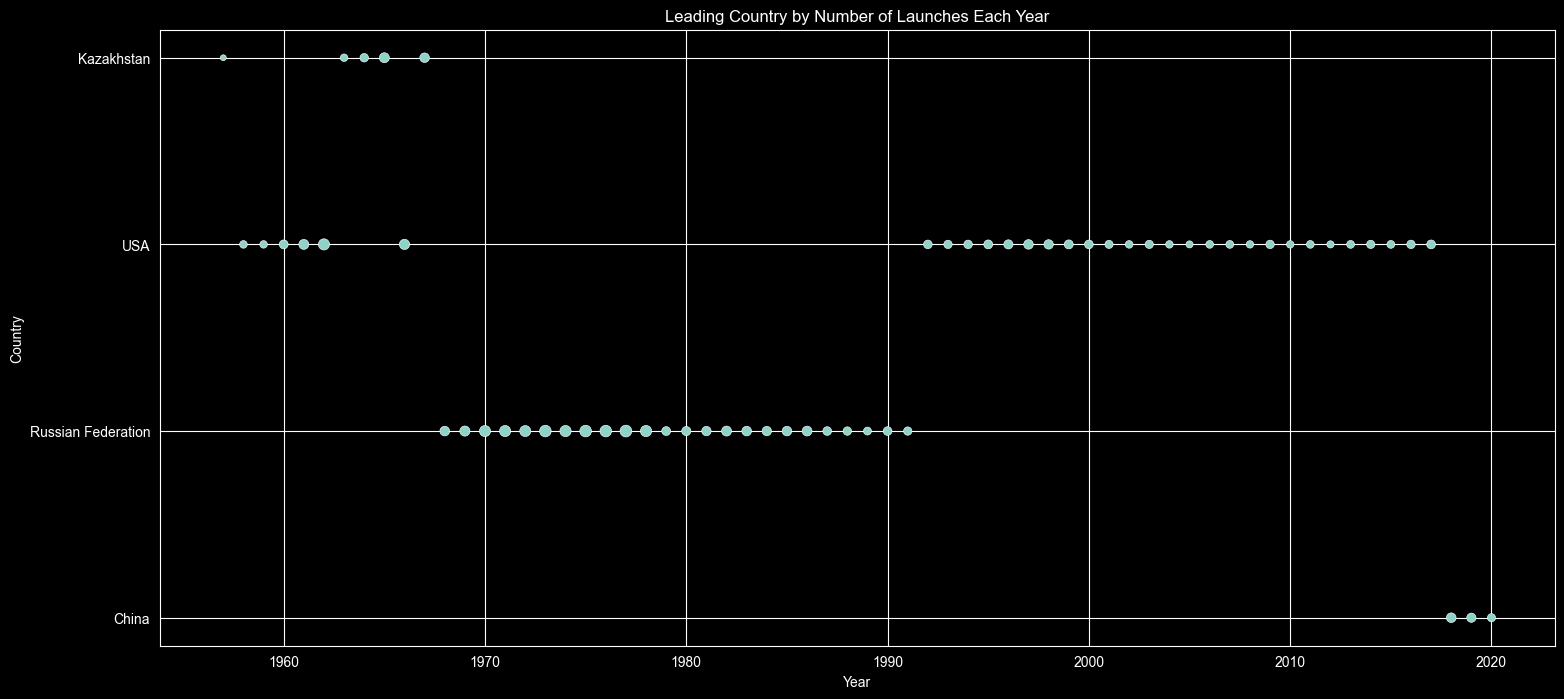

In [147]:
plt.figure(figsize=(18,8))

sns.scatterplot(
    data=country_leaders,
    x="Year",
    y="Country",
    size="Launches",
    legend=False
)

plt.title(
    "Leading Country by Number of Launches Each Year"
)

plt.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [148]:
org_launches = (
    clean_df
    .groupby(
        [
            clean_df["Date"].dt.year,
            "Organisation"
        ]
    )
    .size()
    .reset_index(name="Launches")
)

org_launches.columns = [
    "Year",
    "Organisation",
    "Launches"
]

In [149]:
org_leaders = (
    org_launches
    .sort_values(
        "Launches",
        ascending=False
    )
    .groupby("Year")
    .first()
    .reset_index()
)

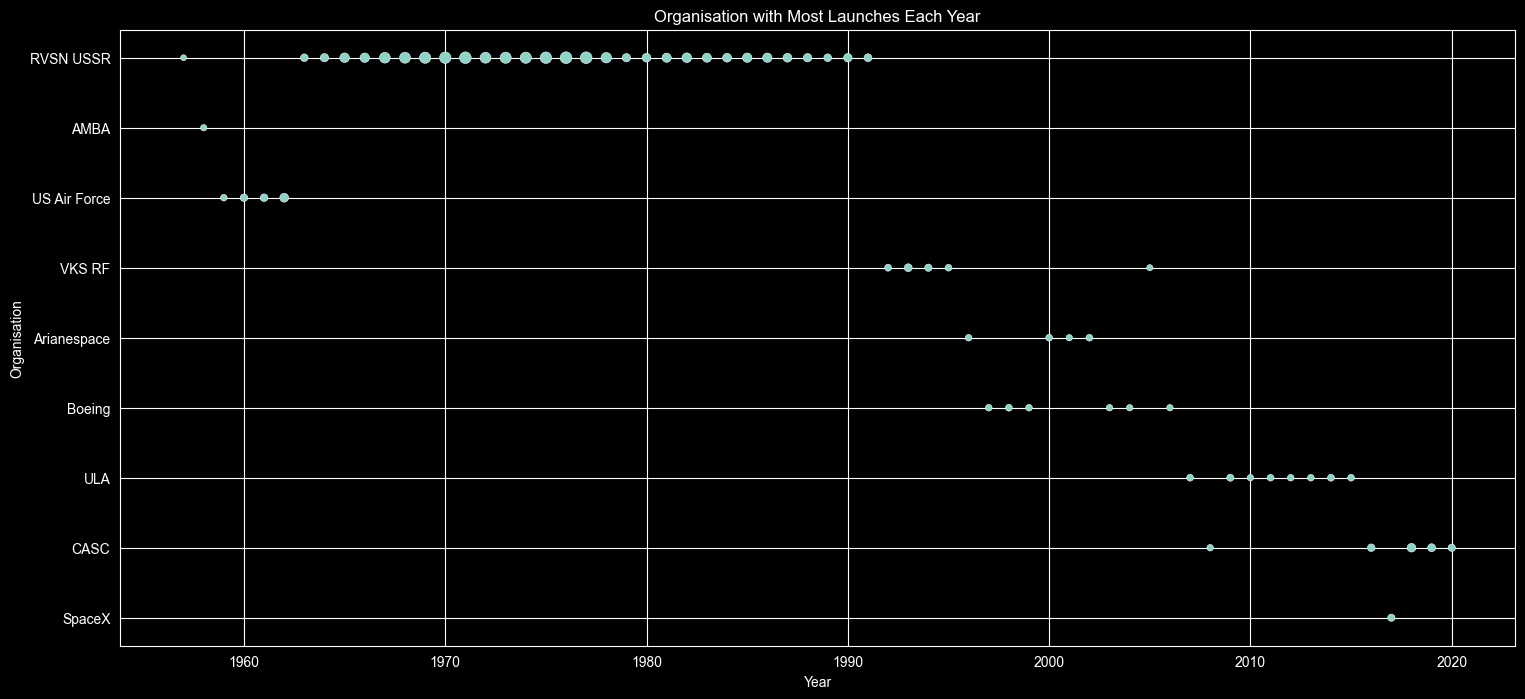

In [151]:
plt.figure(figsize=(18,8))

sns.scatterplot(
    data=org_leaders,
    x="Year",
    y="Organisation",
    size="Launches",
    legend=False
)

plt.title(
    "Organisation with Most Launches Each Year"
)

plt.show()